# 쿨다운 모멘텀 전략 — Grid Search

**목적:** 종목 수(N_MOM)와 최소 보유기간(COOLDOWN_MONTHS)의 최적 조합 탐색

**그리드:**
- N_MOM: [3, 4, 5, 6, 7, 8, 9, 10]
- COOLDOWN_MONTHS: [3, 4, 5, 6]
- 총 32개 조합

**구조:** 데이터 다운로드 1회 → 백테스트 32회 반복 → 히트맵 시각화

In [3]:
# ============================================================
# [CELL 1] CONFIG
# ============================================================
from pathlib import Path

# 이 파일(노트북) 기준으로 project3 루트 찾기
HERE = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
PROJECT_ROOT = HERE.parent        # 최종/ 의 상위가 project3 라는 가정
DATA_DIR = PROJECT_ROOT / "data" / "krx"

CONFIG = {
    # ── 기간 ──
    "START_DATE": "2010-01-01",
    "END_DATE": "2025-01-01",
    "WARMUP_MONTHS": 13,

    # ── 전략 (grid search 대상) ──
    "N_MOM_GRID": [3, 4, 5, 6, 7, 8, 9, 10],
    "COOLDOWN_GRID": [3, 4, 5, 6],

    # ── 고정 파라미터 ──
    "MOM_WEIGHT_12": 0.5,
    "MOM_WEIGHT_6": 0.5,
    "COST_RATE": 0.003,
    "INITIAL_CAPITAL": 100_000_000,

    # ── KRX OHLCV CSV (로컬 데이터) ──
     "KRX_CSV": str(DATA_DIR / "krx_ohlcv_20100101_20261231.csv"),

    # ── 데이터 품질 ──
    "MIN_HISTORY_DAYS": 260,
}

n_combos = len(CONFIG["N_MOM_GRID"]) * len(CONFIG["COOLDOWN_GRID"])
print(f"✅ CONFIG 설정 완료")
print(f"   Grid: {len(CONFIG['N_MOM_GRID'])} × {len(CONFIG['COOLDOWN_GRID'])} = {n_combos}개 조합")
print(f"   N_MOM: {CONFIG['N_MOM_GRID']}")
print(f"   COOLDOWN: {CONFIG['COOLDOWN_GRID']}")

✅ CONFIG 설정 완료
   Grid: 8 × 4 = 32개 조합
   N_MOM: [3, 4, 5, 6, 7, 8, 9, 10]
   COOLDOWN: [3, 4, 5, 6]


In [4]:
# ============================================================
# [CELL 2] 라이브러리
# ============================================================

import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.style.use("fivethirtyeight")

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [ ]:
# ============================================================
# [CELL 3] KRX CSV 로드 & 종목 티커 추출
# ============================================================

csv_path = CONFIG["KRX_CSV"]

df_krx = pd.read_csv(csv_path)
df_krx["Date"] = pd.to_datetime(df_krx["Date"])
df_krx["ticker"] = df_krx["ticker"].astype(str).str.zfill(6)

# 기간 필터
df_krx = df_krx[(df_krx["Date"] >= CONFIG["START_DATE"]) & (df_krx["Date"] <= CONFIG["END_DATE"])]

tickers = sorted(df_krx["ticker"].unique())
print(f"✅ KRX CSV 로드 완료: {csv_path}")
print(f"   총 {len(tickers)}개 종목, {len(df_krx):,}행 데이터")

In [8]:
# ============================================================
# [CELL 4] 데이터 처리 (1회만 실행, 로컬 CSV 기반)
# ============================================================

stocks_monthly = {}
stocks_daily = {}

for t in tqdm(tickers, desc="데이터 처리",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]"):
    sub = df_krx[df_krx["ticker"] == t].set_index("Date").sort_index()

    if len(sub) < CONFIG["MIN_HISTORY_DAYS"]:
        continue

    # 일간 데이터 저장
    stocks_daily[t] = sub[["Close"]].rename(columns={"Close": "Close"})

    # 월간 모멘텀
    monthly = sub["Close"].resample("ME").last().dropna().to_frame("Close")
    monthly["Mom_12_1"] = monthly["Close"].shift(1) / monthly["Close"].shift(12) - 1
    monthly["Mom_6_1"]  = monthly["Close"].shift(1) / monthly["Close"].shift(6) - 1
    w12, w6 = CONFIG["MOM_WEIGHT_12"], CONFIG["MOM_WEIGHT_6"]
    monthly["Momentum"] = w12 * monthly["Mom_12_1"] + w6 * monthly["Mom_6_1"]
    monthly = monthly.dropna(subset=["Momentum"])
    if len(monthly) > 0:
        stocks_monthly[t] = monthly

# 양쪽 다 있는 종목만
valid = set(stocks_daily.keys()) & set(stocks_monthly.keys())
stocks_daily   = {t: v for t, v in stocks_daily.items() if t in valid}
stocks_monthly = {t: v for t, v in stocks_monthly.items() if t in valid}

print(f"\n분석 가능 종목: {len(valid)}개")

데이터 처리:   0%|          | 0/287 [  0%]

데이터 처리: 100%|██████████| 287/287 [100%]


분석 가능 종목: 287개


In [9]:
# ============================================================
# [CELL 5] 리밸런싱 날짜 (1회 생성)
# ============================================================

all_dates = sorted(set().union(*(df.index.tolist() for df in stocks_daily.values())))
daily_index = pd.DatetimeIndex(all_dates)

rebal_dates = daily_index.to_series().groupby(
    [daily_index.year, daily_index.month]
).first().values
rebal_dates = pd.DatetimeIndex(sorted(rebal_dates))

warmup_end = pd.Timestamp(CONFIG["START_DATE"]) + pd.DateOffset(months=CONFIG["WARMUP_MONTHS"])
rebal_dates = rebal_dates[rebal_dates >= warmup_end]

print(f"리밸런싱: {len(rebal_dates)}회")
print(f"기간: {rebal_dates[0].strftime('%Y-%m-%d')} ~ {rebal_dates[-1].strftime('%Y-%m-%d')}")

리밸런싱: 167회
기간: 2011-02-01 ~ 2024-12-02


In [10]:
# ============================================================
# [CELL 6] 백테스트 엔진 (파라미터화)
# ============================================================
#
# run_backtest(n_mom, cooldown_months) 형태로
# CONFIG 대신 인자로 받아 grid search에서 반복 호출 가능
#

def get_exec_price(ticker, date):
    if ticker not in stocks_daily:
        return None
    df = stocks_daily[ticker]
    future = df.loc[date:]
    if future.empty:
        return None
    return future["Close"].iloc[0]


def get_signal_momentum(ticker, rebal_date):
    if ticker not in stocks_monthly:
        return None
    df = stocks_monthly[ticker]
    available = df.loc[:rebal_date - pd.Timedelta(days=1)]
    if available.empty:
        return None
    return available["Momentum"].iloc[-1]


def run_backtest(n_mom, cooldown_months):
    """지정된 N_MOM, COOLDOWN_MONTHS로 백테스트 실행.
    데이터(stocks_monthly, stocks_daily, rebal_dates)는 전역 사용."""

    cash = CONFIG["INITIAL_CAPITAL"]
    holdings = {}
    history = []
    total_traded = 0.0
    COST = CONFIG["COST_RATE"]

    for date in rebal_dates:

        # (A) 포트폴리오 평가
        port_val = cash
        dead = []
        for t, info in holdings.items():
            p = get_exec_price(t, date)
            if p is not None:
                port_val += info["shares"] * p
            else:
                dead.append(t)
        for t in dead:
            del holdings[t]

        # (B) 모멘텀 랭킹
        mom_scores = []
        for t in stocks_monthly.keys():
            mom = get_signal_momentum(t, date)
            price = get_exec_price(t, date)
            if mom is not None and price is not None:
                mom_scores.append((t, mom))
        mom_scores.sort(key=lambda x: x[1], reverse=True)
        ranked = [t for t, _ in mom_scores]

        # (C) 쿨다운 보호
        cooldown_keep = []
        for t, info in holdings.items():
            months_held = ((date.year - info["buy_date"].year) * 12
                           + (date.month - info["buy_date"].month))
            if months_held < cooldown_months:
                cooldown_keep.append(t)

        # (D) 타깃 포트폴리오
        target = cooldown_keep.copy()
        for t in ranked:
            if len(target) >= n_mom:
                break
            if t not in target:
                target.append(t)

        # (E) 매도
        for t in list(holdings.keys()):
            if t not in target:
                p = get_exec_price(t, date)
                if p is None:
                    continue
                traded_val = holdings[t]["shares"] * p
                cash += traded_val * (1 - COST)
                total_traded += traded_val
                del holdings[t]

        # (F) 매수/리밸런싱
        if target:
            current_val = cash
            for t in holdings:
                p = get_exec_price(t, date)
                if p:
                    current_val += holdings[t]["shares"] * p

            alloc = current_val / len(target)

            for t in target:
                p = get_exec_price(t, date)
                if p is None or p <= 0:
                    continue

                cur_s = holdings.get(t, {}).get("shares", 0)
                tar_s = int(alloc // p)
                diff = tar_s - cur_s

                if diff > 0:
                    cost = diff * p * (1 + COST)
                    if cash >= cost:
                        cash -= cost
                        total_traded += diff * p
                        old_date = holdings.get(t, {}).get("buy_date", date)
                        holdings[t] = {
                            "shares": tar_s,
                            "buy_date": old_date if t in holdings else date,
                        }
                elif diff < 0:
                    sell_s = abs(diff)
                    traded_val = sell_s * p
                    cash += traded_val * (1 - COST)
                    total_traded += traded_val
                    holdings[t]["shares"] = tar_s

        # (G) 기록
        final_val = cash
        for t, info in holdings.items():
            p = get_exec_price(t, date)
            if p:
                final_val += info["shares"] * p
        history.append((date, final_val))

    perf_df = pd.DataFrame(history, columns=["Date", "Value"]).set_index("Date")
    return perf_df, total_traded


print("✅ 백테스트 엔진 정의 완료")

✅ 백테스트 엔진 정의 완료


In [11]:
# ============================================================
# [CELL 7] Grid Search 실행
# ============================================================

n_mom_list = CONFIG["N_MOM_GRID"]
cooldown_list = CONFIG["COOLDOWN_GRID"]
n_combos = len(n_mom_list) * len(cooldown_list)

results = []
combo_idx = 0

print(f"Grid Search 시작: {n_combos}개 조합\n")

for n_mom in n_mom_list:
    for cd in cooldown_list:
        combo_idx += 1
        perf_df, traded = run_backtest(n_mom, cd)

        # 지표 계산
        years = max((perf_df.index[-1] - perf_df.index[0]).days / 365.25, 0.1)
        final = perf_df["Value"].iloc[-1]
        init = CONFIG["INITIAL_CAPITAL"]

        cagr = ((final / init) ** (1 / years) - 1) * 100
        mdd = (perf_df["Value"] / perf_df["Value"].cummax() - 1).min() * 100

        monthly = perf_df["Value"].resample("ME").last().pct_change().dropna()
        sharpe = (monthly.mean() * 12) / (monthly.std() * np.sqrt(12)) if monthly.std() > 0 else 0

        turnover = (traded / 2) / perf_df["Value"].mean() / years * 100

        # 월간 승률
        win_rate = (monthly > 0).mean() * 100

        # Calmar Ratio (CAGR / |MDD|)
        calmar = cagr / abs(mdd) if mdd != 0 else 0

        results.append({
            "N_MOM": n_mom,
            "COOLDOWN": cd,
            "CAGR(%)": round(cagr, 2),
            "MDD(%)": round(mdd, 2),
            "Sharpe": round(sharpe, 2),
            "Calmar": round(calmar, 3),
            "Turnover(%)": round(turnover, 1),
            "WinRate(%)": round(win_rate, 1),
            "최종자산": int(final),
        })

        print(f"  [{combo_idx:2d}/{n_combos}] N={n_mom}, CD={cd}m "
              f"→ CAGR={cagr:+.2f}%, MDD={mdd:.2f}%, Sharpe={sharpe:.2f}")

results_df = pd.DataFrame(results)
print(f"\n✅ Grid Search 완료")

Grid Search 시작: 32개 조합

  [ 1/32] N=3, CD=3m → CAGR=+17.27%, MDD=-59.41%, Sharpe=0.53
  [ 2/32] N=3, CD=4m → CAGR=+23.35%, MDD=-58.94%, Sharpe=0.63
  [ 3/32] N=3, CD=5m → CAGR=+3.22%, MDD=-81.91%, Sharpe=0.28
  [ 4/32] N=3, CD=6m → CAGR=+13.50%, MDD=-66.32%, Sharpe=0.49
  [ 5/32] N=4, CD=3m → CAGR=+14.16%, MDD=-63.77%, Sharpe=0.50
  [ 6/32] N=4, CD=4m → CAGR=+11.54%, MDD=-71.93%, Sharpe=0.46
  [ 7/32] N=4, CD=5m → CAGR=+12.81%, MDD=-72.04%, Sharpe=0.48
  [ 8/32] N=4, CD=6m → CAGR=+10.50%, MDD=-77.46%, Sharpe=0.46
  [ 9/32] N=5, CD=3m → CAGR=+15.33%, MDD=-55.95%, Sharpe=0.54
  [10/32] N=5, CD=4m → CAGR=+13.09%, MDD=-62.39%, Sharpe=0.49
  [11/32] N=5, CD=5m → CAGR=+7.84%, MDD=-83.34%, Sharpe=0.38
  [12/32] N=5, CD=6m → CAGR=+10.14%, MDD=-77.19%, Sharpe=0.43
  [13/32] N=6, CD=3m → CAGR=+15.21%, MDD=-59.87%, Sharpe=0.55
  [14/32] N=6, CD=4m → CAGR=+17.45%, MDD=-46.77%, Sharpe=0.61
  [15/32] N=6, CD=5m → CAGR=+14.99%, MDD=-64.62%, Sharpe=0.55
  [16/32] N=6, CD=6m → CAGR=+10.19%, MDD=-74.59%

In [12]:
# ============================================================
# [CELL 8] 결과 테이블 (전체)
# ============================================================

print(f"{'='*70}")
print(f"  Grid Search 전체 결과 (CAGR 내림차순)")
print(f"{'='*70}")

sorted_df = results_df.sort_values("CAGR(%)", ascending=False).reset_index(drop=True)
sorted_df.index = sorted_df.index + 1  # 1-based rank
sorted_df.index.name = "Rank"

display(sorted_df.style
        .format({"CAGR(%)": "{:+.2f}", "MDD(%)": "{:.2f}", "Sharpe": "{:.2f}",
                 "Calmar": "{:.3f}", "Turnover(%)": "{:.1f}", "WinRate(%)": "{:.1f}",
                 "최종자산": "{:,.0f}"})
        .background_gradient(subset=["CAGR(%)"], cmap="RdYlGn")
        .background_gradient(subset=["Sharpe"], cmap="RdYlGn")
        .background_gradient(subset=["MDD(%)"], cmap="RdYlGn_r")
        .set_properties(**{"text-align": "center", "padding": "6px"}))

  Grid Search 전체 결과 (CAGR 내림차순)


,N_MOM,COOLDOWN,CAGR(%),MDD(%),Sharpe,Calmar,Turnover(%),WinRate(%),최종자산
Rank,,,,,,,,,
1,3,4,+23.35,-58.94,0.63,0.396,161.6,49.4,"1,822,978,877"
2,8,5,+20.37,-42.37,0.71,0.481,216.6,53.6,"1,299,242,661"
3,8,6,+17.85,-41.86,0.65,0.427,200.1,51.2,"970,486,461"
4,9,5,+17.61,-43.30,0.66,0.407,219.9,53.6,"943,106,544"
5,6,4,+17.45,-46.77,0.61,0.373,224.0,51.2,"926,010,967"
6,3,3,+17.27,-59.41,0.53,0.291,185.8,48.8,"906,536,664"
7,10,6,+17.07,-40.55,0.67,0.421,206.8,53.0,"885,414,575"
8,7,5,+16.56,-50.81,0.60,0.326,208.0,47.0,"832,818,238"
9,9,6,+16.53,-44.41,0.63,0.372,203.5,53.0,"829,945,426"


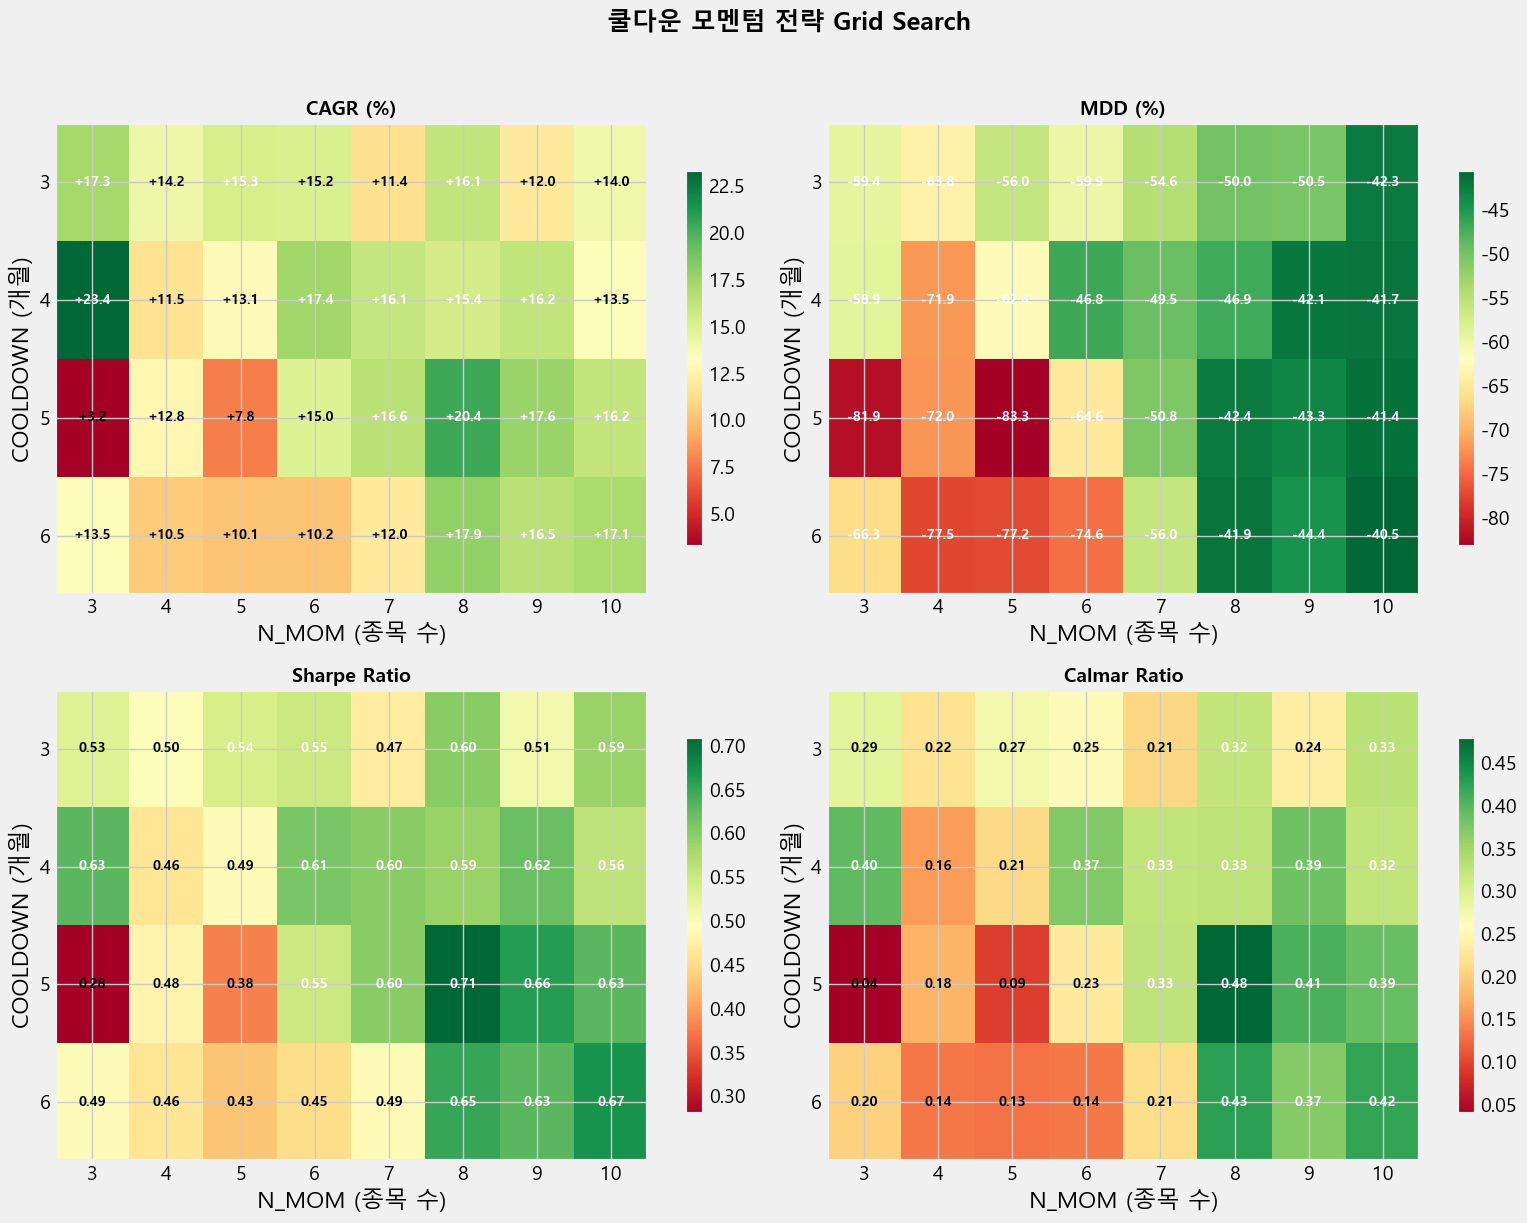

In [13]:
# ============================================================
# [CELL 9] 히트맵 시각화 — CAGR / MDD / Sharpe / Calmar
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = [
    ("CAGR(%)",    "CAGR (%)",     "RdYlGn",   None),
    ("MDD(%)",     "MDD (%)",      "RdYlGn",   None),
    ("Sharpe",     "Sharpe Ratio", "RdYlGn",   None),
    ("Calmar",     "Calmar Ratio", "RdYlGn",   None),
]

for ax, (col, title, cmap, _) in zip(axes.flat, metrics_to_plot):
    pivot = results_df.pivot(index="COOLDOWN", columns="N_MOM", values=col)

    # 셀 값 표시
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")

    # 축 라벨
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("N_MOM (종목 수)")
    ax.set_ylabel("COOLDOWN (개월)")
    ax.set_title(title, fontsize=14, fontweight="bold")

    # 셀에 값 표기
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            fmt = f"{val:+.1f}" if col in ["CAGR(%)", "MDD(%)"] else f"{val:.2f}"
            ax.text(j, i, fmt, ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if abs(val) > (pivot.values.max() - pivot.values.min()) * 0.6 + pivot.values.min() else "black")

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("쿨다운 모멘텀 전략 Grid Search", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# [CELL 10] 최적 조합 Top 5 상세
# ============================================================

print(f"{'='*60}")
print(f"  CAGR 기준 Top 5")
print(f"{'='*60}")
top5_cagr = results_df.nlargest(5, "CAGR(%)")
display(top5_cagr.style.format({
    "CAGR(%)": "{:+.2f}", "MDD(%)": "{:.2f}", "Sharpe": "{:.2f}",
    "Calmar": "{:.3f}", "Turnover(%)": "{:.1f}", "최종자산": "{:,.0f}"
}).hide(axis="index").set_properties(**{"text-align": "center", "padding": "8px"}))

print(f"\n{'='*60}")
print(f"  Sharpe 기준 Top 5")
print(f"{'='*60}")
top5_sharpe = results_df.nlargest(5, "Sharpe")
display(top5_sharpe.style.format({
    "CAGR(%)": "{:+.2f}", "MDD(%)": "{:.2f}", "Sharpe": "{:.2f}",
    "Calmar": "{:.3f}", "Turnover(%)": "{:.1f}", "최종자산": "{:,.0f}"
}).hide(axis="index").set_properties(**{"text-align": "center", "padding": "8px"}))

print(f"\n{'='*60}")
print(f"  Calmar(CAGR/|MDD|) 기준 Top 5 — 리스크 대비 수익")
print(f"{'='*60}")
top5_calmar = results_df.nlargest(5, "Calmar")
display(top5_calmar.style.format({
    "CAGR(%)": "{:+.2f}", "MDD(%)": "{:.2f}", "Sharpe": "{:.2f}",
    "Calmar": "{:.3f}", "Turnover(%)": "{:.1f}", "최종자산": "{:,.0f}"
}).hide(axis="index").set_properties(**{"text-align": "center", "padding": "8px"}))

  CAGR 기준 Top 5


N_MOM,COOLDOWN,CAGR(%),MDD(%),Sharpe,Calmar,Turnover(%),WinRate(%),최종자산
3,4,+23.35,-58.94,0.63,0.396,161.6,49.400000,"1,822,978,877"
8,5,+20.37,-42.37,0.71,0.481,216.6,53.600000,"1,299,242,661"
8,6,+17.85,-41.86,0.65,0.427,200.1,51.200000,"970,486,461"
9,5,+17.61,-43.30,0.66,0.407,219.9,53.600000,"943,106,544"
6,4,+17.45,-46.77,0.61,0.373,224.0,51.200000,"926,010,967"



  Sharpe 기준 Top 5


N_MOM,COOLDOWN,CAGR(%),MDD(%),Sharpe,Calmar,Turnover(%),WinRate(%),최종자산
8,5,+20.37,-42.37,0.71,0.481,216.6,53.600000,"1,299,242,661"
10,6,+17.07,-40.55,0.67,0.421,206.8,53.000000,"885,414,575"
9,5,+17.61,-43.30,0.66,0.407,219.9,53.600000,"943,106,544"
8,6,+17.85,-41.86,0.65,0.427,200.1,51.200000,"970,486,461"
3,4,+23.35,-58.94,0.63,0.396,161.6,49.400000,"1,822,978,877"



  Calmar(CAGR/|MDD|) 기준 Top 5 — 리스크 대비 수익


N_MOM,COOLDOWN,CAGR(%),MDD(%),Sharpe,Calmar,Turnover(%),WinRate(%),최종자산
8,5,+20.37,-42.37,0.71,0.481,216.6,53.600000,"1,299,242,661"
8,6,+17.85,-41.86,0.65,0.427,200.1,51.200000,"970,486,461"
10,6,+17.07,-40.55,0.67,0.421,206.8,53.000000,"885,414,575"
9,5,+17.61,-43.30,0.66,0.407,219.9,53.600000,"943,106,544"
3,4,+23.35,-58.94,0.63,0.396,161.6,49.400000,"1,822,978,877"


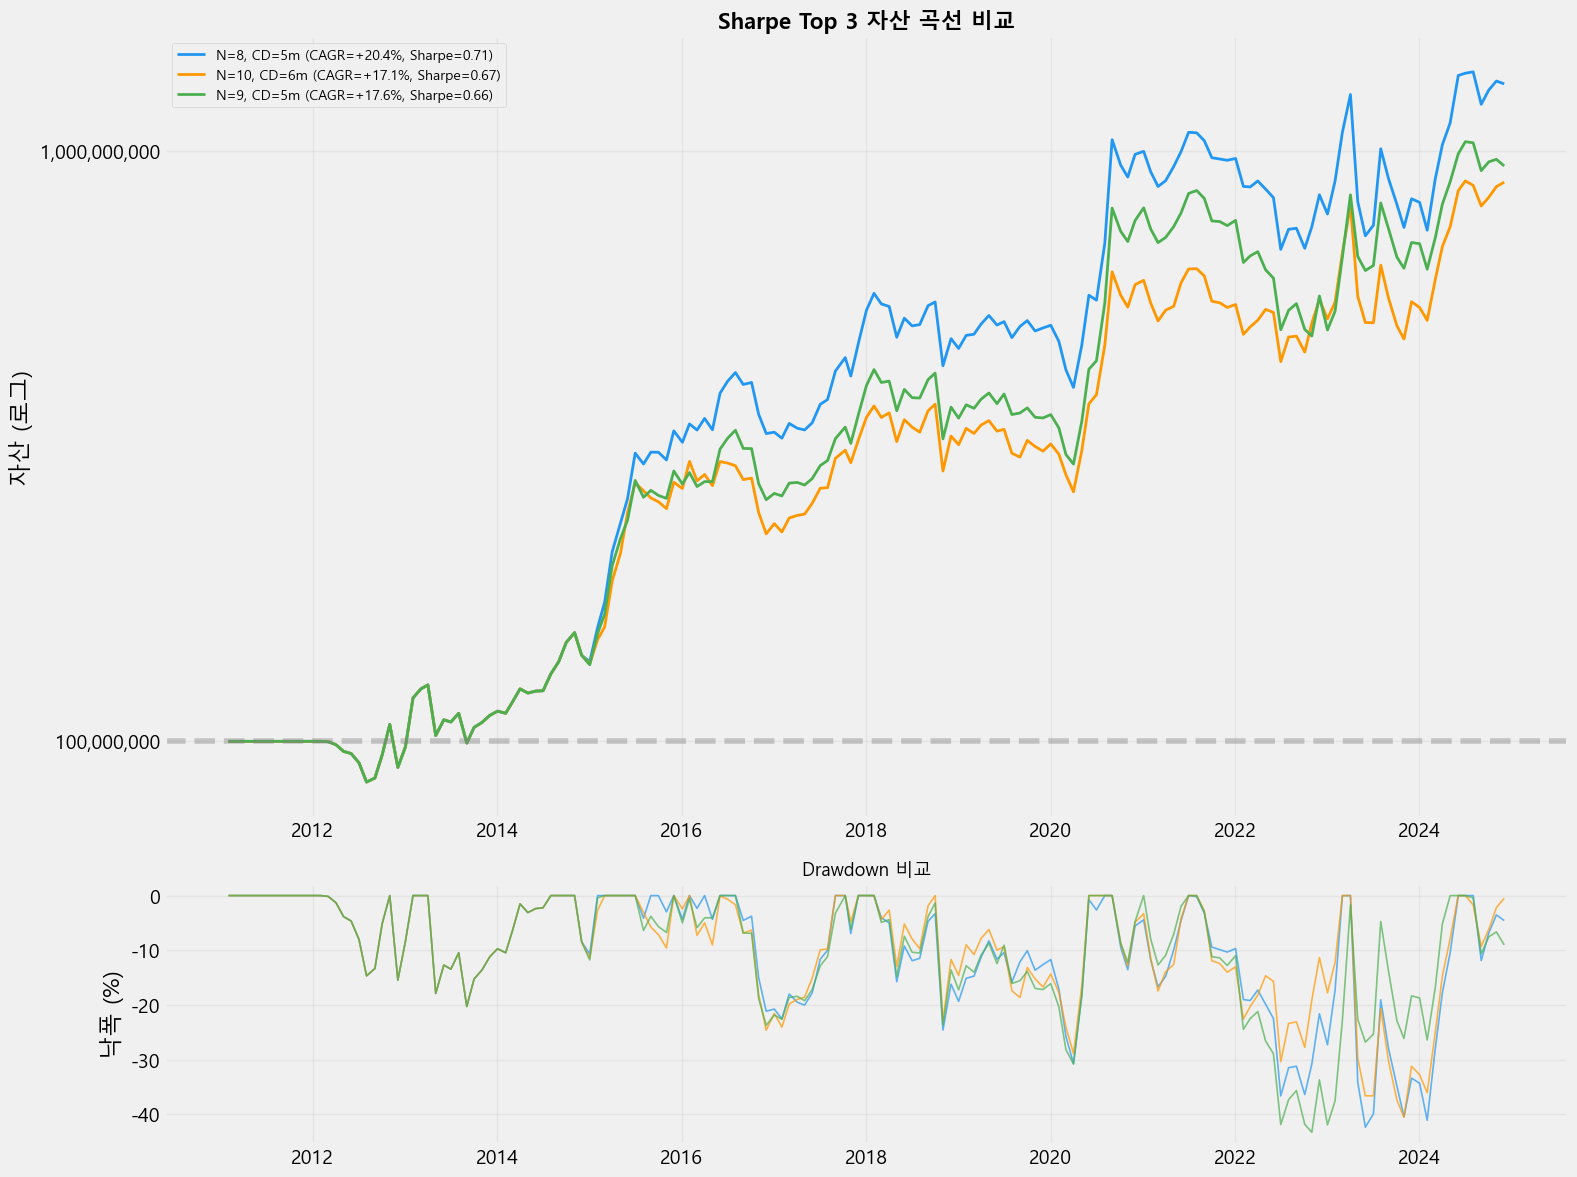

In [15]:
# ============================================================
# [CELL 11] Top 3 자산 곡선 비교
# ============================================================

# Sharpe 기준 Top 3
top3 = results_df.nlargest(3, "Sharpe")

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})

colors = ["#2196F3", "#FF9800", "#4CAF50"]
labels = []
equity_curves = []

for idx, (_, row) in enumerate(top3.iterrows()):
    n, cd = int(row["N_MOM"]), int(row["COOLDOWN"])
    pf, _ = run_backtest(n, cd)
    equity_curves.append(pf)

    label = f"N={n}, CD={cd}m (CAGR={row['CAGR(%)']:+.1f}%, Sharpe={row['Sharpe']:.2f})"
    labels.append(label)

    axes[0].plot(pf.index, pf["Value"], lw=2, color=colors[idx], label=label)

    dd = (pf["Value"] / pf["Value"].cummax() - 1) * 100
    axes[1].plot(dd.index, dd.values, lw=1.2, color=colors[idx], alpha=0.7)

axes[0].axhline(y=CONFIG["INITIAL_CAPITAL"], color="gray", ls="--", alpha=0.4)
axes[0].set_yscale("log")
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
axes[0].set_title("Sharpe Top 3 자산 곡선 비교", fontsize=16, fontweight="bold")
axes[0].set_ylabel("자산 (로그)")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("낙폭 (%)")
axes[1].set_title("Drawdown 비교", fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# [CELL 12] 파라미터 민감도 요약
# ============================================================

print(f"{'='*60}")
print(f"  N_MOM별 평균 성과 (쿨다운 평균)")
print(f"{'='*60}")
by_n = results_df.groupby("N_MOM")[["CAGR(%)", "MDD(%)", "Sharpe", "Calmar", "Turnover(%)"]].mean().round(2)
display(by_n.style.background_gradient(cmap="RdYlGn", subset=["CAGR(%)", "Sharpe", "Calmar"])
        .set_properties(**{"text-align": "center", "padding": "8px"}))

print(f"\n{'='*60}")
print(f"  COOLDOWN별 평균 성과 (N_MOM 평균)")
print(f"{'='*60}")
by_cd = results_df.groupby("COOLDOWN")[["CAGR(%)", "MDD(%)", "Sharpe", "Calmar", "Turnover(%)"]].mean().round(2)
display(by_cd.style.background_gradient(cmap="RdYlGn", subset=["CAGR(%)", "Sharpe", "Calmar"])
        .set_properties(**{"text-align": "center", "padding": "8px"}))

print("\n※ 특정 조합이 압도적으로 좋다면 오버피팅 가능성. 넓은 구간에서 안정적인 조합이 실전에 유리.")

  N_MOM별 평균 성과 (쿨다운 평균)


,CAGR(%),MDD(%),Sharpe,Calmar,Turnover(%)
N_MOM,,,,,
3,14.340000,-66.640000,0.480000,0.230000,163.950000
4,12.250000,-71.300000,0.480000,0.170000,193.150000
5,11.600000,-69.720000,0.460000,0.180000,207.550000
6,14.460000,-61.460000,0.540000,0.250000,217.400000
7,14.010000,-52.750000,0.540000,0.270000,224.700000
8,17.450000,-45.280000,0.640000,0.390000,232.300000
9,15.580000,-45.080000,0.600000,0.350000,237.650000
10,15.200000,-41.500000,0.610000,0.370000,241.420000



  COOLDOWN별 평균 성과 (N_MOM 평균)


,CAGR(%),MDD(%),Sharpe,Calmar,Turnover(%)
COOLDOWN,,,,,
3,14.440000,-54.550000,0.540000,0.270000,247.710000
4,15.840000,-52.540000,0.570000,0.310000,223.880000
5,13.700000,-59.980000,0.540000,0.270000,200.510000
6,13.470000,-59.800000,0.530000,0.260000,186.960000



※ 특정 조합이 압도적으로 좋다면 오버피팅 가능성. 넓은 구간에서 안정적인 조합이 실전에 유리.
